In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
%matplotlib inline

In [3]:
transfer_data = pd.read_csv("uk_record_transfers.csv")

In [4]:
transfer_data["year"] = transfer_data["year"].astype("int64")
transfer_data["fee_gbp"] = pd.to_numeric(transfer_data["fee_gbp"], errors="coerce").astype("int64")
transfer_data = (
    transfer_data
    .drop_duplicates(["year", "player", "fee_gbp"])
    .sort_values(["year", "fee_gbp"])
    .reset_index(drop=True)
)


In [5]:
milestones = [100, 1000, 10_000, 100_000, 1_000_000, 10_000_000, 100_000_000, 125_000_000]

milestone_rows = []
for m in milestones:
    hit = transfer_data.loc[transfer_data["fee_gbp"] >= m].sort_values("year").head(1)
    if not hit.empty:
        milestone_rows.append(hit.assign(milestone=m))

milestone_df = pd.concat(milestone_rows, ignore_index=True)

milestone_year_df = (
    milestone_df
    .groupby(["year", "player", "fee_gbp"], as_index=False)["milestone"]
    .apply(list)
)



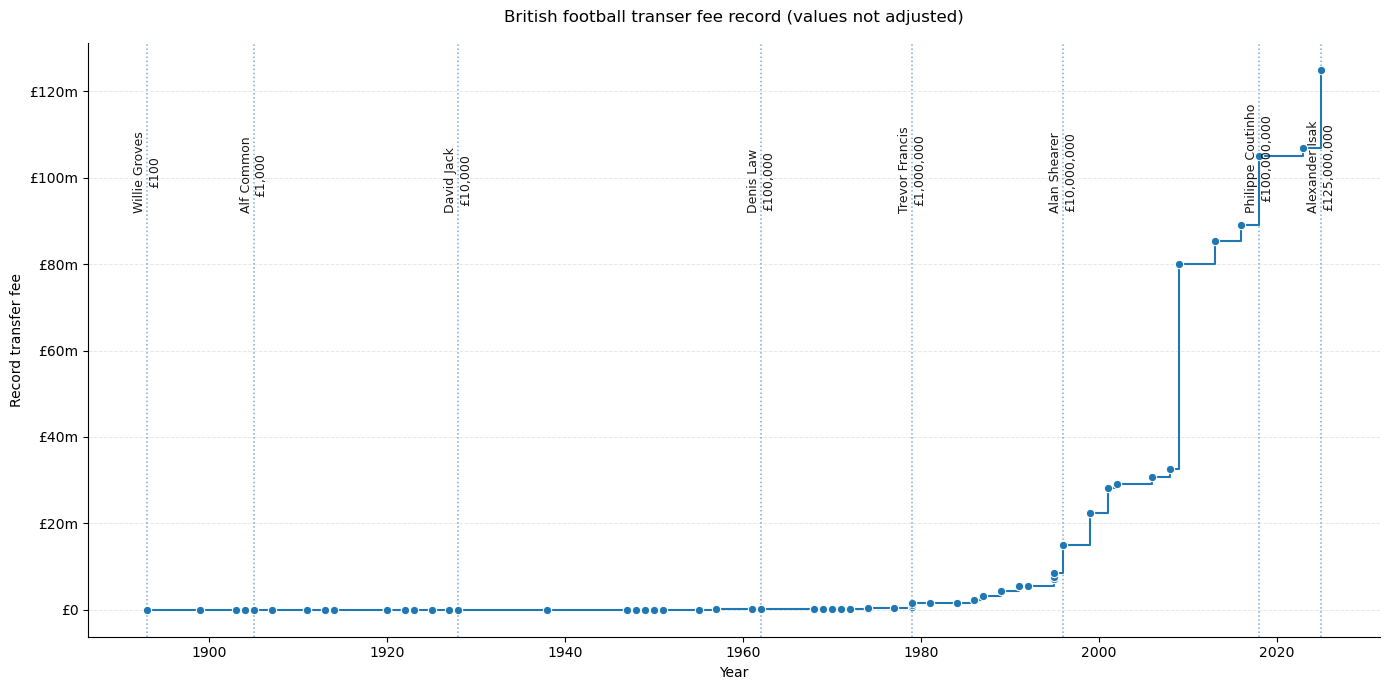

In [14]:
fig, ax = plt.subplots(figsize=(14,7))

sns.lineplot(
    data=transfer_data,
    x="year", y="fee_gbp",
    marker="o",
    estimator=None, errorbar=None,
    drawstyle="steps-post",
    ax=ax
)

# £ axis formatter (human readable)
def pounds_fmt(x, pos):
    if x >= 1_000_000:
        return f"£{x/1_000_000:.0f}m"
    return f"£{int(x):,}"

ax.yaxis.set_major_formatter(mtick.FuncFormatter(pounds_fmt))

ax.set_xlabel("Year")
ax.set_ylabel("Record transfer fee")
ax.set_title("British football transer fee record (values not adjusted)", pad=15)


# subtle grid (y only)
ax.grid(True, axis="y", linestyle="--", linewidth=0.7, alpha=0.30)
ax.grid(False, axis="x")

# milestone overlays (anchored near bottom)
y0, y1 = ax.get_ylim()
label_y = y1*0.7

for _, r in milestone_year_df.iterrows():
    ax.axvline(r["year"], linestyle=":", linewidth=1.1, alpha=0.6)
    ms_txt = ", ".join([f"£{int(m):,}" for m in sorted(r["milestone"])])
    ax.text(
        r["year"], label_y,
        f'{r["player"]}\n{ms_txt}',
        ha="center", va="bottom",
        fontsize=9, rotation=90, alpha=0.9
    )

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("record_transfer_history.png", dpi=400)

plt.show()

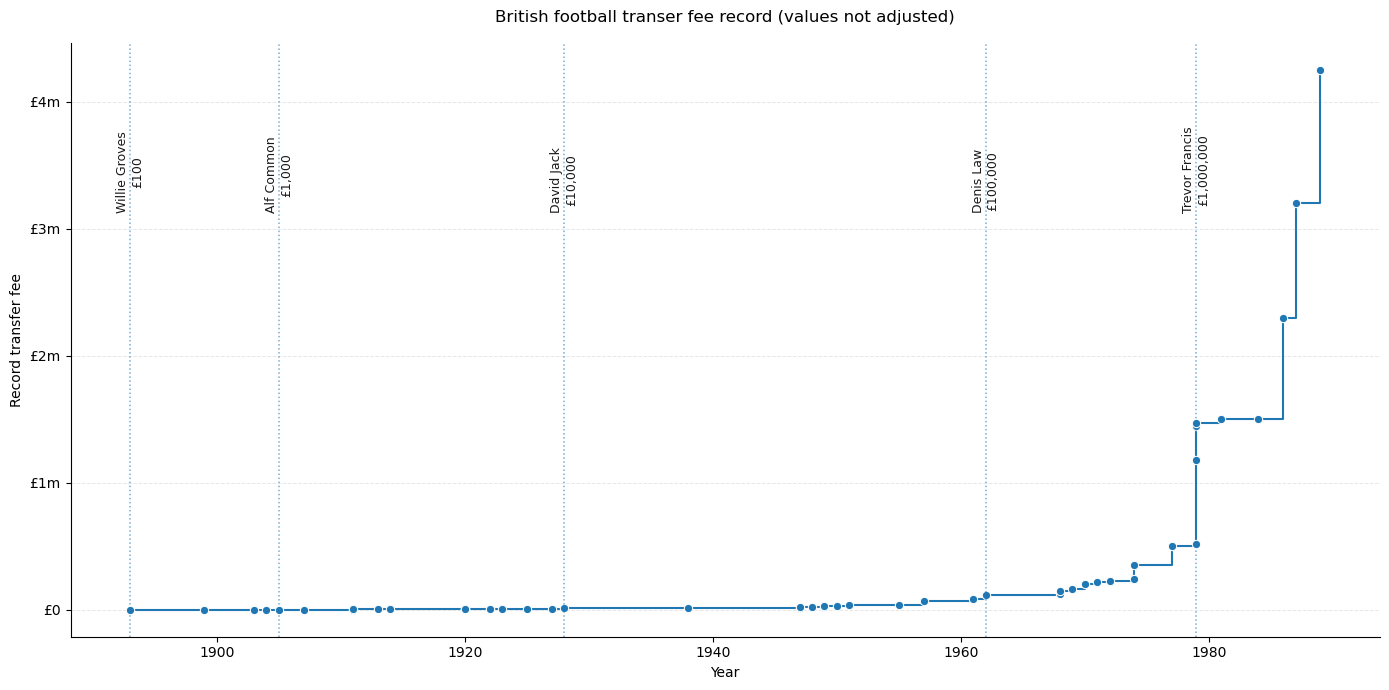

In [16]:

transfer_data_limited = transfer_data[transfer_data['year'] < 1990]
milestones = [100, 1000, 10_000, 100_000, 1_000_000, 10_000_000, 100_000_000, 125_000_000]

milestone_rows = []
for m in milestones:
    hit = transfer_data_limited.loc[transfer_data_limited["fee_gbp"] >= m].sort_values("year").head(1)
    if not hit.empty:
        milestone_rows.append(hit.assign(milestone=m))

milestone_df = pd.concat(milestone_rows, ignore_index=True)

milestone_year_df = (
    milestone_df
    .groupby(["year", "player", "fee_gbp"], as_index=False)["milestone"]
    .apply(list)
)
fig, ax = plt.subplots(figsize=(14,7))

sns.lineplot(
    data=transfer_data_limited,
    x="year", y="fee_gbp",
    marker="o",
    estimator=None, errorbar=None,
    drawstyle="steps-post",
    ax=ax
)

# £ axis formatter (human readable)
def pounds_fmt(x, pos):
    if x >= 1_000_000:
        return f"£{x/1_000_000:.0f}m"
    return f"£{int(x):,}"

ax.yaxis.set_major_formatter(mtick.FuncFormatter(pounds_fmt))

ax.set_xlabel("Year")
ax.set_ylabel("Record transfer fee")
ax.set_title("British football transer fee record (values not adjusted)", pad=15)


# subtle grid (y only)
ax.grid(True, axis="y", linestyle="--", linewidth=0.7, alpha=0.30)
ax.grid(False, axis="x")

# milestone overlays (anchored near bottom)
y0, y1 = ax.get_ylim()
label_y = y1*0.7

for _, r in milestone_year_df.iterrows():
    ax.axvline(r["year"], linestyle=":", linewidth=1.1, alpha=0.6)
    ms_txt = ", ".join([f"£{int(m):,}" for m in sorted(r["milestone"])])
    ax.text(
        r["year"], label_y,
        f'{r["player"]}\n{ms_txt}',
        ha="center", va="bottom",
        fontsize=9, rotation=90, alpha=0.9
    )

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("record_transfer_history_limited.png", dpi=400)

plt.show()